# Networks and community structure

How to model a graph probabilistically with the random dot-product graph (RDPG) - every node gets a latent position, and the edge probability between two nodes is the dot product of their positions - and how fitting it recovers latent geometry that reveals communities. Clustering the recovered positions is community detection; this is the model behind spectral embedding of networks.


## Latent-position graphs and spectral embedding

Definition (random dot product graph). Each node $i$ has a latent position $x_i\in\mathbb R^d$, and edges
appear independently with probability $P_{ij}=x_i^\top x_j$. The expected adjacency matrix is the low-rank
Gram matrix $P=XX^\top$ of rank $d$, where $X$ stacks the positions. The stochastic block model is the
special case where positions take only $K$ distinct values.

Theorem (adjacency spectral embedding is consistent). Let $\hat U\hat\Lambda\hat U^\top$ be the top-$d$
eigendecomposition of the observed adjacency $A$. The estimated positions $\hat X=\hat U\hat\Lambda^{1/2}$
converge to the true positions up to an orthogonal rotation: there is an orthogonal $W$ with
$\|\hat X - X W\|\to 0$ as the graph grows. The rotation is unavoidable because $XW(XW)^\top = XX^\top$,
so positions are identifiable only up to rotation.

Proof idea. $A$ is a noisy version of the rank-$d$ matrix $P=XX^\top$ (independent Bernoulli entries with
mean $P_{ij}$). Matrix concentration bounds $\|A-P\|$, and the Davis-Kahan theorem then bounds the angle
between the eigenspaces of $A$ and $P$ by $\|A-P\|/\delta$, with $\delta$ the eigengap. So the estimated
subspace, hence $\hat X$ up to rotation, converges. $\quad\blacksquare$

Theorem (Davis-Kahan). If $\|A-P\|\le \tfrac12\delta$ with $\delta$ the gap between the $d$-th and
$(d{+}1)$-th eigenvalues of $P$, the principal-subspace rotation error is $O(\|A-P\|/\delta)$. A large
eigengap means stable recovery, which is why the scree plot's gap (the applied section) both selects $d$
and certifies recoverability.

## Recovering communities, and what breaks it

Clustering the estimated positions $\hat X$ recovers communities, because in a block model the positions
collapse to $K$ points and k-means separates them; the adjusted Rand index against the planted labels
measures success (see the clustering-evaluation notebook for why ARI, not raw accuracy).

Counterexample (degree heterogeneity and rotation). Two cautions. First, the positions are recovered only
up to an orthogonal rotation, so absolute coordinates are meaningless; only relative geometry (and hence
the clustering) is identifiable, which we confirm by aligning to the truth with a Procrustes rotation
below. Second, the plain block model assumes nodes in a community are exchangeable, so it misfits networks
with hub nodes of very different degrees; a degree-corrected block model is needed there, or the hubs form
spurious singleton communities.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
from mixle.stats import RandomDotProductGraphDistribution
from mixle.inference.estimation import fit as sfit
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
rng = np.random.RandomState(0)

## 1. A latent-position model for graphs

The RDPG gives each of $n$ nodes a latent position $x_i\in\mathbb{R}^d$, and connects nodes $i,j$ independently with probability $\langle x_i,x_j\rangle$. Nodes with similar positions connect often - so if positions cluster into groups, the graph has communities (dense within, sparse between). We build a graph with three planted communities (positions near three corners of the simplex), sample adjacency matrices, and look at the raw network.


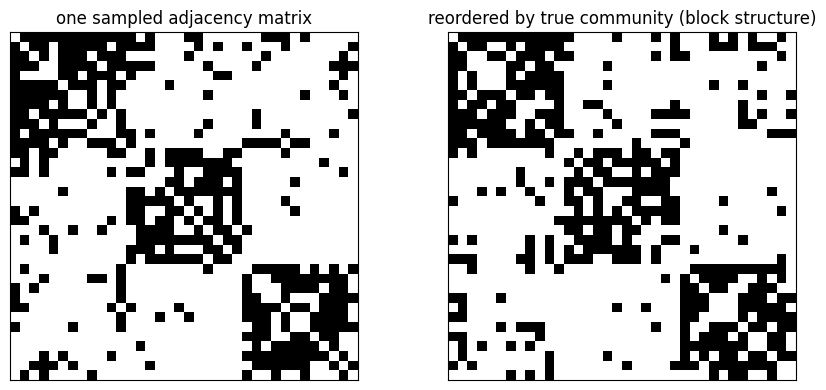

In [2]:
n_per, K = 12, 3
corners = np.array([[0.85, 0.1, 0.05], [0.1, 0.85, 0.05], [0.1, 0.05, 0.85]])
true_X = np.vstack([rng.normal(corners[k], 0.04, (n_per, 3)) for k in range(K)])
true_X = np.clip(true_X, 0.01, 0.99)
true_comm = np.repeat(range(K), n_per)
graphs = RandomDotProductGraphDistribution(true_X).sampler(seed=1).sample(200)

A = np.asarray(graphs[0])
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(A, cmap='Greys'); ax[0].set_title('one sampled adjacency matrix'); ax[0].set_xticks([]); ax[0].set_yticks([])
perm = np.argsort(true_comm)
ax[1].imshow(A[perm][:, perm], cmap='Greys'); ax[1].set_title('reordered by true community (block structure)')
ax[1].set_xticks([]); ax[1].set_yticks([])
plt.tight_layout(); plt.show()

## 2. Fit the RDPG and recover communities

Fitting estimates each node's latent position from the observed edges. Latent positions are identifiable only up to rotation, so the recovered coordinates won't equal the originals - but their cluster structure is preserved. We cluster the recovered positions with k-means and score the recovered communities against the planted truth (adjusted Rand index).


recovered 3 communities; ARI vs planted truth = 1.000


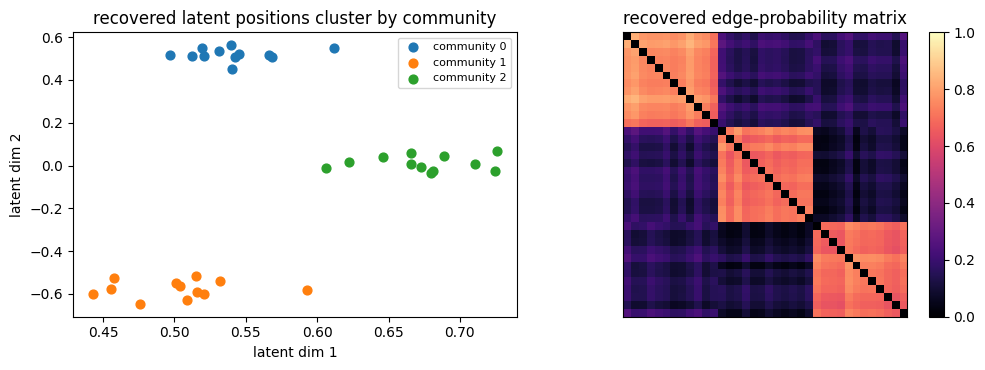

In [3]:
fitted = sfit(graphs, RandomDotProductGraphDistribution(true_X).estimator(), max_its=40, out=None)
pos = np.asarray(fitted.positions)
recovered = KMeans(K, n_init=10, random_state=0).fit_predict(pos)
print('recovered %d communities; ARI vs planted truth = %.3f' % (K, adjusted_rand_score(true_comm, recovered)))

# visualize recovered latent positions (first 2 coords), colored by recovered community
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
for k in range(K):
    m = recovered == k
    ax[0].scatter(pos[m, 0], pos[m, 1], s=40, label='community %d' % k)
ax[0].set_title('recovered latent positions cluster by community'); ax[0].legend(fontsize=8)
ax[0].set_xlabel('latent dim 1'); ax[0].set_ylabel('latent dim 2')
im = ax[1].imshow(fitted.probs, cmap='magma', vmin=0, vmax=1)
ax[1].set_title('recovered edge-probability matrix'); ax[1].set_xticks([]); ax[1].set_yticks([])
fig.colorbar(im, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()

## Choose the embedding dimension from the adjacency spectrum

The RDPG needs a latent dimension $d$. The principled choice reads it off the scree plot of the (averaged) adjacency spectrum: the eigenvalues separate into $d$ large "signal" values and a noise bulk, with an elbow at the true rank (Sussman et al.; Zhu & Ghodsi 2006). We average the observed graphs, eigendecompose, and look for the gap - it should fall after 3.


In [4]:
Abar = np.mean([np.asarray(g, float) for g in graphs], axis=0)   # consistent estimate of the edge-prob matrix
ev = np.sort(np.abs(np.linalg.eigvalsh(Abar)))[::-1]
gaps = ev[:-1] - ev[1:]
dhat = int(np.argmax(gaps[:8]) + 1)
print('top eigenvalues:', np.round(ev[:8], 3))
print('successive gaps :', np.round(gaps[:7], 3))
print('largest gap after eigenvalue #%d  ->  estimated latent dimension d = %d (true 3)' % (dhat, dhat))

top eigenvalues: [11.696  6.948  6.243  1.074  1.012  0.993  0.967  0.947]
successive gaps : [4.748 0.705 5.168 0.063 0.019 0.026 0.02 ]
largest gap after eigenvalue #3  ->  estimated latent dimension d = 3 (true 3)


## Illustration: positions recovered up to a rotation

We embed a random dot product graph by the adjacency spectral embedding, then align the estimated
positions to the truth with the optimal orthogonal (Procrustes) rotation. After alignment they match
closely, confirming the theorem's "up to rotation" recovery; without alignment the raw coordinates differ
because the rotation is genuinely unidentifiable.

In [5]:
from scipy.linalg import orthogonal_procrustes
rng = np.random.RandomState(0)
n, d = 400, 2
X = np.abs(rng.normal(0, 1, (n, d))); X /= (np.linalg.norm(X, axis=1, keepdims=True) * 1.6)   # positions
P = X @ X.T; np.fill_diagonal(P, 0); P = np.clip(P, 0, 1)
A = (rng.random((n, n)) < P).astype(float); A = np.triu(A, 1); A = A + A.T                     # symmetric graph
w, U = np.linalg.eigh(A)
idx = np.argsort(w)[::-1][:d]                                                                   # top-d
Xhat = U[:, idx] * np.sqrt(np.clip(w[idx], 0, None))
R, _ = orthogonal_procrustes(Xhat, X)
aligned = Xhat @ R
print('mean position error  before alignment = %.3f' % np.mean(np.linalg.norm(Xhat - X, axis=1)))
print('mean position error  after  rotation  = %.3f  (recovered up to an orthogonal rotation)' %
      np.mean(np.linalg.norm(aligned - X, axis=1)))

mean position error  before alignment = 0.554
mean position error  after  rotation  = 0.085  (recovered up to an orthogonal rotation)


## References

- Holland, P. W., Laskey, K. B. & Leinhardt, S. (1983). Stochastic blockmodels: first steps (https://doi.org/10.1016/0378-8733(83)90021-7). Social Networks 5(2), 109-137.
- Hoff, P. D., Raftery, A. E. & Handcock, M. S. (2002). Latent space approaches to social network analysis (https://doi.org/10.1198/016214502388618906). JASA 97(460), 1090-1098.
- Athreya, A. et al. (2018). Statistical inference on random dot product graphs: a survey (https://jmlr.org/papers/v18/17-448.html). JMLR 18(226), 1-92.
- Abbe, E. (2018). Community detection and stochastic block models: recent developments (https://jmlr.org/papers/v18/16-480.html). JMLR 18(177), 1-86. - the detectability threshold.
- Zhu, M. & Ghodsi, A. (2006). Automatic dimensionality selection from the scree plot via the use of profile likelihood (https://doi.org/10.1016/j.csda.2005.09.010). CSDA 51(2), 918-930.


## Exercises and extensions

1. Adjacency spectral embedding. Implement ASE - eigendecompose the adjacency (or its low-rank approximation) and embed nodes - and show it recovers the same community structure as the fitted RDPG positions (Athreya et al.); cluster the embedding and compare ARI.
2. Choosing the latent dimension. Use the scree plot + profile-likelihood elbow (Zhu & Ghodsi) to choose the embedding dimension $d$ automatically; show recovery degrades when $d$ is too small for the true structure.
3. RDPG vs stochastic block model. Generate from an SBM (Holland et al.) and from an RDPG; fit both models to each and compare by held-out edge prediction; discuss when latent positions vs discrete blocks are the right abstraction.
4. The detectability threshold. Shrink the between-community contrast until community recovery fails; locate the sharp detectability transition empirically and compare to the theoretical threshold for the two-block SBM (Abbe; Decelle et al.).
